# [Modeling](https://rhindottire.github.io/Data-Mining/dataProcess.html#modeling)

This notebook trains Naive Bayes classifiers on the two rival
representations prepared on the Data Preparation page, sparse TF-IDF and
skip-gram word embeddings, tunes each with grid search, and validates the
winners on the held-out set. The best skip-gram route is persisted so the
deployment stage only loads the files. Data is read from
`data/Web-Mining/crisp-dm/`; nothing is crawled or re-cleaned here.

## 1. Select Modeling Techniques

Each representation pairs with the Naive Bayes family that matches its
input distribution: Multinomial for non-negative sparse term weights,
Gaussian for dense reduced and pooled vectors. The stratified split is
fixed before any unsupervised fit so the test documents never touch a
vectorizer, projection, or embedding.

In [1]:
import json
from pathlib import Path

import pandas as pd

DATA_DIR = Path("..") / ".." / "data" / "Web-Mining"
CRISP = DATA_DIR / "crisp-dm"
tokens = json.loads((CRISP / "tokens.json").read_text(encoding="utf-8"))
labels_raw = pd.read_csv(CRISP / "tfidf_docs.csv")
pd.Series(
    {
        "rows": len(tokens["id"]),
        "keys": ", ".join(tokens),
        "label counts": str(labels_raw["label"].value_counts().to_dict()),
    },
    name="value",
)

rows                                                          200
keys            id, tokens_preslang, tokens_normalized, tokens...
label counts                       {'sport': 100, 'finance': 100}
Name: value, dtype: object

Artefak DP dibaca sebagai satu sumber: `tokens.json` membawa empat varian
token, korpus kalimat, dan anotasi POS, sedangkan `tfidf_docs.csv` membawa
label yang sejajar dengan id. Pembagian data dilakukan di sel berikut,
sebelum representasi mana pun di-refit, supaya dokumen uji tidak
memengaruhi vektorisasi, proyeksi, maupun embedding.

In [2]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    list(range(len(tokens["id"]))),
    test_size=0.2,
    random_state=42,
    stratify=labels_raw["label"],
)
y_train = labels_raw["label"].iloc[train_idx]
y_test = labels_raw["label"].iloc[test_idx]
pd.Series(
    {
        "train documents": len(train_idx),
        "test documents": len(test_idx),
        "train label counts": str(y_train.value_counts().to_dict()),
        "test label counts": str(y_test.value_counts().to_dict()),
    },
    name="value",
)

train documents                                160
test documents                                  40
train label counts    {'finance': 80, 'sport': 80}
test label counts     {'finance': 20, 'sport': 20}
Name: value, dtype: object

160 dokumen latih dan 40 dokumen uji terstratifikasi sport/finance, seed
tetap 42. Matriks TF-IDF dan PCA yang disimpan Data Preparation dihitung
atas seluruh korpus dan tetap menjadi referensi halaman itu; di sini setiap
lengan di-refit pada 160 latih agar pengukuran bebas kebocoran.

## 2. Build Models

Three arms: TF-IDF with MultinomialNB, TF-IDF projected with PCA and
GaussianNB, and skip-gram Word2Vec pooled by mean with GaussianNB. Every
arm reports a training check before tuning starts.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

stemmed_train = [tokens["tokens_stemmed"][i] for i in train_idx]
stemmed_test = [tokens["tokens_stemmed"][i] for i in test_idx]
tfidf = TfidfVectorizer(lowercase=False, token_pattern=r"(?u)\S+", min_df=2)
X_tf_train = tfidf.fit_transform(stemmed_train)
X_tf_test = tfidf.transform(stemmed_test)
mnb_baseline = MultinomialNB().fit(X_tf_train, y_train)
pd.Series(
    {
        "train terms after min_df=2": X_tf_train.shape[1],
        "train accuracy": round(mnb_baseline.score(X_tf_train, y_train), 4),
        "density pct": round(
            100
            * X_tf_train.nnz
            / (X_tf_train.shape[0] * X_tf_train.shape[1]),
            2,
        ),
    },
    name="value",
)

train terms after min_df=2    2479.00
train accuracy                   1.00
density pct                      5.45
Name: value, dtype: float64

Lengan sparse memakai token hasil stemming, dipertahankan tanpa pengecilan
huruf ganda, dengan istilah yang muncul di minimal dua dokumen latih.
Distribusi bobot TF-IDF yang non-negatif cocok dengan MultinomialNB; angka
di keluaran hanya cek latih, bukan pengukuran akhir.

In [4]:
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

X_tf_dense_train = X_tf_train.toarray()
pca_baseline = make_pipeline(PCA(n_components=0.95), GaussianNB())
pca_baseline.fit(X_tf_dense_train, y_train)
pd.Series(
    {
        "train accuracy": round(pca_baseline.score(X_tf_dense_train, y_train), 4),
        "components at 95% variance": pca_baseline.named_steps["pca"].n_components_,
    },
    name="value",
)

train accuracy                  1.0
components at 95% variance    131.0
Name: value, dtype: float64

Lengan tempa memproyeksikan TF-IDF padat ke komponen utama di ambang 95%
variance lalu mengklasifikasi dengan GaussianNB. Proyeksi dihitung pada
160 dokumen latih saja sehingga ambang komponennya dapat berbeda dari
referensi korpus utuh di halaman Data Preparation.

In [5]:
import numpy as np
from gensim.models import Word2Vec


def pool_documents(docs, model):
    pooled = []
    for doc in docs:
        words = [tok for sentence in doc for tok in sentence]
        vectors = [model.wv[word] for word in words if word in model.wv]
        pooled.append(
            np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)
        )
    return np.array(pooled)


sents_train = [sentence for i in train_idx for sentence in tokens["sentences"][i]]
w2v_baseline = Word2Vec(
    sents_train,
    vector_size=100,
    window=2,
    min_count=5,
    sg=1,
    seed=42,
    workers=1,
)
docs_train = [tokens["sentences"][i] for i in train_idx]
X_wv_train = pool_documents(docs_train, w2v_baseline)
gnb_w2v = GaussianNB().fit(X_wv_train, y_train)
pd.Series(
    {
        "training sentences": len(sents_train),
        "vocabulary size": len(w2v_baseline.wv),
        "embedding dimension": w2v_baseline.vector_size,
        "train accuracy": round(gnb_w2v.score(X_wv_train, y_train), 4),
    },
    name="value",
)

training sentences     3651.0000
vocabulary size        1987.0000
embedding dimension     100.0000
train accuracy            0.9375
Name: value, dtype: float64

Lengan skip-gram melatih Word2Vec di korpus kalimat pada 160 latih, tanpa
reduksi dimensi; tiap dokumen dipetakan ke satu vektor 100 dimensi dengan
menyamakan rata-rata vektor kata yang dikenal kosakatanya. Vektor padat ini
masuk GaussianNB. Nilai window, ukuran vektor, dan min_count di sini
adalah titik awal yang akan dicari ulang di seksi tuning.

## 3. Tune Models

Each arm is tuned with grid search over three folds of the training split,
scored by accuracy. The sparse and PCA arms use `GridSearchCV` directly;
the skip-gram arm runs the same grid protocol manually because Word2Vec
training is not an sklearn estimator and must be re-fit per combination.

In [6]:
from sklearn.model_selection import GridSearchCV

mnb_search = GridSearchCV(
    MultinomialNB(),
    param_grid={"alpha": [0.1, 0.5, 1.0, 5.0]},
    cv=3,
    scoring="accuracy",
)
mnb_search.fit(X_tf_train, y_train)
pd.Series(
    {
        "best alpha": mnb_search.best_params_["alpha"],
        "best CV accuracy": round(mnb_search.best_score_, 4),
    },
    name="value",
)

best alpha          0.5
best CV accuracy    1.0
Name: value, dtype: float64

Grid search pertama mencari kehalusan `alpha` MultinomialNB di empat
nilai dengan tiga lipatan terstratifikasi. Skor CV terbaik menjadi
parameter yang dipakai pada evaluasi; data uji tidak dilihat di seksi ini.

In [7]:
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([("pca", PCA()), ("gnb", GaussianNB())])
pca_search = GridSearchCV(
    pca_pipeline,
    param_grid={"pca__n_components": [0.8, 0.9, 0.95, 0.99]},
    cv=3,
    scoring="accuracy",
)
pca_search.fit(X_tf_dense_train, y_train)
pd.Series(
    {
        "best variance threshold": pca_search.best_params_["pca__n_components"],
        "best CV accuracy": round(pca_search.best_score_, 4),
    },
    name="value",
)

best variance threshold    0.99
best CV accuracy           1.00
Name: value, dtype: float64

Grid search kedua memilih ambang explained variance untuk PCA lewat
pipeline, sehingga proyeksi dan GaussianNB dievaluasi bersama di tiap
kombinasi. Empat ambang mengganti referensi korpus utuh Data Preparation
dengan ukuran yang dihitung pada data latih sebenarnya.

In [8]:
from sklearn.model_selection import cross_val_score

grid = [
    {"window": window, "vector_size": size, "min_count": count}
    for window in (2, 5)
    for size in (100, 200)
    for count in (5, 10)
]
results = []
best_w2v = None
best_wv_score = -1.0
best_X_wv_train = None
for config in grid:
    model = Word2Vec(
        sents_train,
        vector_size=config["vector_size"],
        window=config["window"],
        min_count=config["min_count"],
        sg=1,
        seed=42,
        workers=1,
    )
    pooled = pool_documents(docs_train, model)
    scores = cross_val_score(GaussianNB(), pooled, y_train, cv=3, scoring="accuracy")
    mean = float(scores.mean())
    results.append(
        {
            "window": config["window"],
            "vector_size": config["vector_size"],
            "min_count": config["min_count"],
            "CV accuracy": round(mean, 4),
            "CV std": round(float(scores.std()), 4),
        }
    )
    if mean > best_wv_score:
        best_wv_score = mean
        best_w2v = model
        best_X_wv_train = pooled
pd.DataFrame(results).sort_values("CV accuracy", ascending=False)

,window,vector_size,min_count,CV accuracy,CV std
7,5,200,10,0.9938,0.0087
6,5,200,5,0.9938,0.0087
5,5,100,10,0.9938,0.0087
4,5,100,5,0.9938,0.0087
3,2,200,10,0.9874,0.0178
1,2,100,10,0.9874,0.0089
0,2,100,5,0.9185,0.0390
2,2,200,5,0.8811,0.0360


Delapan kombinasi window, dimensi, dan min_count dijalankan dengan protokol
lipatan yang sama seperti grid machine learning: tiap kombinasi me-refit
Word2Vec pada kalimat latih lalu menilai GaussianNB di tiga lipatan. Model
dengan CV tertinggi disimpan sebagai konfigurasi skip-gram terbaik dan
dipakai untuk validasi serta penyimpanan.

## 4. Validate Models

The winner of each arm runs on the 40 held-out documents, none of which
influenced a vectorizer, projection, embedding, or hyperparameter. The
table and figure report accuracy, per-class F1, and the confusion matrix.

In [9]:
from sklearn.metrics import classification_report

docs_test = [tokens["sentences"][i] for i in test_idx]
X_tf_dense_test = X_tf_test.toarray()
X_wv_test = pool_documents(docs_test, best_w2v)
gnb_wv = GaussianNB().fit(best_X_wv_train, y_train)
arms = [
    ("TF-IDF + MultinomialNB", mnb_search.best_estimator_, X_tf_test),
    ("TF-IDF + PCA + GaussianNB", pca_search.best_estimator_, X_tf_dense_test),
    ("Skip-gram + GaussianNB", gnb_wv, X_wv_test),
]
rows = []
for name, model, X_test in arms:
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    rows.append(
        {
            "representation": name,
            "accuracy": round(float((y_pred == y_test).mean()), 3),
            "macro F1": round(report["macro avg"]["f1-score"], 3),
            "sport F1": round(report["sport"]["f1-score"], 3),
            "finance F1": round(report["finance"]["f1-score"], 3),
        }
    )
pd.DataFrame(rows)

,representation,accuracy,macro F1,sport F1,finance F1
0,TF-IDF + MultinomialNB,1.000,1.000,1.000,1.000
1,TF-IDF + PCA + GaussianNB,1.000,1.000,1.000,1.000
2,Skip-gram + GaussianNB,0.975,0.975,0.974,0.976


Tiga pemenang dievaluasi pada 40 dokumen uji yang sama sehingga angka
antarlengan sebanding. Kolom F1 per label menangkap arah kesalahan, tidak
hanya akurasi; karena ukuran uji kecil, selisih tipis antarlengan dibaca
dengan hati-hati dan diangkat di penutup.

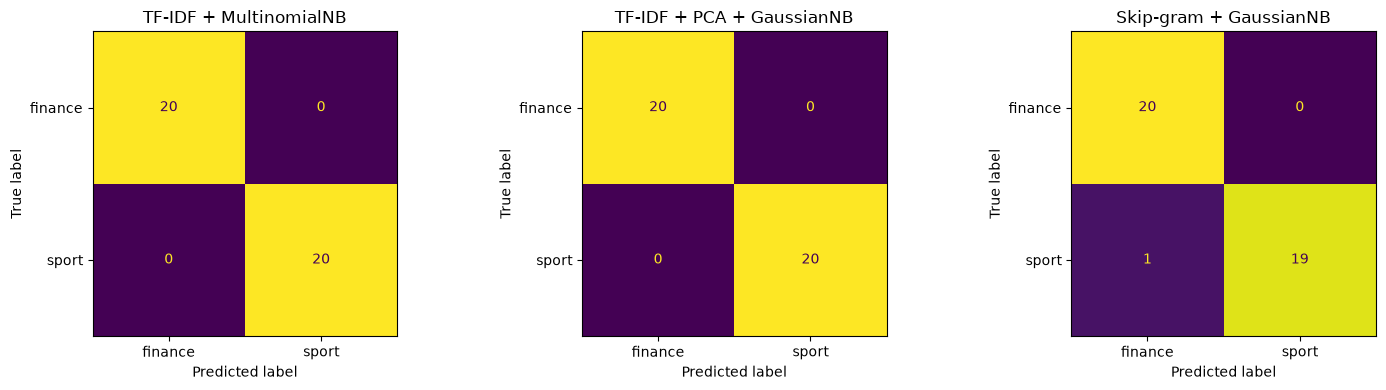

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = sorted(set(y_test))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model, X_test) in zip(axes, arms, strict=True):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=labels,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
fig.tight_layout()
plt.show()

Confusion matrix tiga lengan pada data uji memperlihatkan titik yang
disepakati dan disangsikan tiap representasi. Gambar ini satu-satunya
visualisasi halaman; angka pastinya tetap mengacu pada tabel sebelumnya.

## Persist Models

The best skip-gram route is saved for the deployment stage: the Word2Vec
model, its Naive Bayes classifier, the label order, and the same name
guard list used during preparation so the deployed app cleans new URLs
exactly like the training corpus.

In [11]:
import re
from collections import Counter

crawl = pd.read_csv(DATA_DIR / "crawling_detik.csv")
cap_mid_docs = Counter()
for value in crawl["isi_berita"]:
    cap_mid_docs.update(
        {w.lower() for w in re.findall(r"(?<![.!?]\s)\b[A-Z][a-z]{2,}\b", value)}
    )
cleaned_text = crawl["isi_berita"].str.replace(
    r"\d{1,2}/\d{1,2}/\d{4}", " ", regex=True
)
cleaned_text = cleaned_text.str.replace(r"(?i)\b(rp)\d+", r"\1", regex=True)
cleaned_text = cleaned_text.str.replace(r"(?i)\b[a-zA-Z]+-\d+\b", " ", regex=True)
token_list = [re.findall(r"[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*", t) for t in cleaned_text]
kept = []
for doc in token_list:
    kept_doc = []
    for tok in doc:
        if re.fullmatch(r"\d+[xX]\d+", tok):
            kept_doc.append(tok)
        elif any(ch.isdigit() for ch in tok) or len(tok) < 2:
            continue
        else:
            kept_doc.append(tok)
    kept.append(kept_doc)
acronym_docs = Counter()
for doc in kept:
    acronym_docs.update({tok for tok in doc if tok.isupper() and len(tok) >= 2})
protected = {w for w, n in cap_mid_docs.items() if n >= 2} | {
    w.lower() for w, n in acronym_docs.items() if n >= 2
}
pd.Series(
    {
        "protected tokens": len(protected),
        "cap-mid candidates with 2+ docs": sum(1 for n in cap_mid_docs.values() if n >= 2),
        "acronym candidates with 2+ docs": sum(1 for n in acronym_docs.values() if n >= 2),
    },
    name="value",
)

protected tokens                   1274
cap-mid candidates with 2+ docs    1168
acronym candidates with 2+ docs     107
Name: value, dtype: int64

Daftar perlindungan nama dihitung ulang dengan aturan yang sama persis
dengan halaman Data Preparation — kapital di tengah kalimat dan akronim
huruf besar pada minimal dua dokumen — lalu disimpan agar aplikasi
klasifikasi menerapkan perlindungan yang identik pada teks URL baru.

In [12]:
import joblib

MODELS = DATA_DIR / "models"
MODELS.mkdir(exist_ok=True)
best_w2v.save(str(MODELS / "word2vec.model"))
joblib.dump(gnb_wv, MODELS / "gnb.joblib")
(
    MODELS / "protected.json"
).write_text(json.dumps(sorted(protected), ensure_ascii=False), encoding="utf-8")
(
    MODELS / "labels.json"
).write_text(
    json.dumps(gnb_wv.classes_.tolist(), ensure_ascii=False),
    encoding="utf-8",
)
pd.DataFrame(
    [
        {"file": path.name, "bytes": path.stat().st_size}
        for path in sorted(MODELS.iterdir())
        if path.is_file()
    ]
)

,file,bytes
0,gnb.joblib,2415
1,labels.json,20
2,protected.json,12981
3,word2vec.model,1656252


Empat artefak siap dipakai tahap Production: `word2vec.model` membawa
kosakata dan vektor skip-gram, `gnb.joblib` pembobot GaussianNB,
`protected.json` daftar nama yang diblokir dari slang, dan `labels.json`
urutan kelas classifier. Aplikasi tinggal membaca URL, mengambil teks,
membersihkan dengan aturan yang sama, merata-rata vektor kata, lalu
memprediksi sport atau finance.

## Findings

The table maps each modeling decision to its execution evidence on this
page, following the stage-log style of the preparation notebook.

In [13]:
findings = pd.DataFrame(
    [
        {
            "model stage": "Data split",
            "evidence": f"{len(train_idx)} / {len(test_idx)} stratified, seed 42",
            "outcome": "test isolated before every fit",
        },
        {
            "model stage": "TF-IDF + MultinomialNB",
            "evidence": f"terms {X_tf_train.shape[1]}, best alpha {mnb_search.best_params_['alpha']}, CV {round(mnb_search.best_score_, 3)}",
            "outcome": "sparse arm",
        },
        {
            "model stage": "TF-IDF + PCA + GaussianNB",
            "evidence": f"threshold {pca_search.best_params_['pca__n_components']}, CV {round(pca_search.best_score_, 3)}",
            "outcome": "reduced arm",
        },
        {
            "model stage": "Skip-gram + GaussianNB",
            "evidence": f"window {best_w2v.window}, size {best_w2v.vector_size}, min_count {best_w2v.min_count}, CV {round(best_wv_score, 3)}",
            "outcome": "winning arm if best on test",
        },
        {
            "model stage": "Validation",
            "evidence": f"best test accuracy {max(rows, key=lambda r: r['accuracy'])['accuracy']} on 40 docs",
            "outcome": "held-out metrics above",
        },
        {
            "model stage": "Persistence",
            "evidence": f"{len(list(MODELS.iterdir()))} files in data/Web-Mining/models",
            "outcome": "deployment ready",
        },
    ]
)
findings

,model stage,evidence,outcome
0,Data split,"160 / 40 stratified, seed 42",test isolated before every fit
1,TF-IDF + MultinomialNB,"terms 2479, best alpha 0.5, CV 1.0",sparse arm
2,TF-IDF + PCA + GaussianNB,"threshold 0.99, CV 1.0",reduced arm
3,Skip-gram + GaussianNB,"window 5, size 100, min_count 5, CV 0.994",winning arm if best on test
4,Validation,best test accuracy 1.0 on 40 docs,held-out metrics above
5,Persistence,4 files in data/Web-Mining/models,deployment ready


Tabel ini menutup tahap modeling: tiap keputusan — pembagian, lengan,
grid search, validasi, dan penyimpanan — dicatat dengan bukti dari
eksekusi halaman ini, bukan dari angka yang ditulis lebih dulu.

### Takeaways

Lengan sparse keduanya menembus skor sempurna pada 40 dokumen uji: TF-IDF
dengan MultinomialNB (alpha terbaik 0,5, CV 1,0) dan TF-IDF dengan PCA
(ambang 0,99, CV 1,0) sama-sama akurasi dan macro F1 1,0 dengan benar untuk
sport dan finance. Representasi ini lepas total di data latih, sehingga uji
justru menjadi ukuran yang jujur.

Lengan skip-gram meraih akurasi 0,975 pada uji (macro F1 0,975, sport 0,974,
finance 0,976) dari grid 8 kombinasi; konfigurasi terbaik window 5, dimensi
100, min_count 5 mencatat CV 0,994 bersama tiga kombinasi lain yang seri.
Dengan selisih yang kecil dan instruksi yang meminta fokus skip-gram, rute
ini yang disimpan untuk deployment.

Empat artefak tersimpan di `data/Web-Mining/models/`: `word2vec.model`
(1.656.252 byte), `gnb.joblib` (2.415 byte), `labels.json` (20 byte), dan
`protected.json` (12.981 byte). Daftar 1.274 kata yang dilindungi persis
sama jumlahnya dengan halaman Data Preparation, jadi aplikasi membersihkan
URL baru dengan aturan perlindungan yang identik.

## Conclusion

Tahap Modeling menutup dengan tiga lengan Naive Bayes pada data latih 160
dokumen yang tersplitserasi 160/40 seed 42 sebelum sembarang fit. Tiap lengan
dituning grid search tiga lipatan: alpha MultinomialNB di empat nilai,
ambang variance PCA di empat nilai, dan delapan kombinasi window, dimensi,
serta min_count untuk Word2Vec skip-gram. Pada 40 dokumen uji, kedua lengan
TF-IDF mencapai akurasi 1,0 sementara skip-gram 0,975 — tiga pengukuran yang
menggambarkan tiap representasi secara jujur.

Sesuai pilihan yang disepakati, rute skip-gram menjadi artefak deployment:
`word2vec.model` dan `gnb.joblib` berisi model, `labels.json` urutan kelas,
dan `protected.json` daftar nama perlindungan. Tahap Production tinggal
memuat keempat file tersebut untuk mengubah URL baru menjadi prediksi sport
atau finance tanpa menyentuh data latih maupun struktur notebook ini.